<a href="https://colab.research.google.com/github/Auta01/Tensorflow-cases/blob/main/cnn%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RE-INTRODUCTION TO COMPUTER VISION WITH TENSORFLOW

In [3]:
#geting our data
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
#unzip the downloaded file

zip_ref = zipfile.ZipFile('pizza_steak.zip')
zip_ref.extractall()
zip_ref.close()


--2026-01-27 21:13:38--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.250.141.207, 142.251.2.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip.1’

pizza_steak.zip.1   100%[===================>] 104.47M   282MB/s    in 0.4s    

2026-01-27 21:13:38 (282 MB/s) - ‘pizza_steak.zip.1’ saved [109540975/109540975]



In [4]:
#Becoming one with the data
!ls pizza_steak

test  train


In [5]:
!ls pizza_steak.zip

pizza_steak.zip


In [6]:
import os
# walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk('pizza_steak'):
  print(f'There are {len(dirnames)} directories and {len(filenames)} images in{len(dirpath)}' '.')

There are 2 directories and 0 images in11.
There are 2 directories and 0 images in16.
There are 0 directories and 250 images in22.
There are 0 directories and 250 images in22.
There are 2 directories and 0 images in17.
There are 0 directories and 750 images in23.
There are 0 directories and 750 images in23.


In [7]:
!ls pizza_steak

test  train


In [8]:
#The extra file in our piza_steak directory is 'DS_store'
!ls -la pizza_steak

total 16
drwxr-xr-x 4 root root 4096 Jan 27 21:13 .
drwxr-xr-x 1 root root 4096 Jan 27 21:13 ..
drwxr-xr-x 4 root root 4096 Jan 27 21:13 test
drwxr-xr-x 4 root root 4096 Jan 27 21:13 train


In [9]:
#Another way to find out how many images are in a file
num_steak_images_train = len(os.listdir('pizza_steak/train/steak'))

num_steak_images_train

750

In [10]:
#get the class names programatically
import pathlib
import numpy as np
data_dir = pathlib.Path('pizza/steak/train')
class_names = np.array(sorted([item.name for item in data_dir.glob('*')])) #create the list from the train folder
class_names = class_names[1:]
print(class_names)


[]


In [11]:
#lets visualise our images

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  #setup the target directory (we ll view images from here)
  target_folder = target_dir+target_class

  #get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)
  print(random_image)

  #read the image and  plot it using matplotlib
  img = mpimg.imread(target_folder+'/'+ random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis('off')

  print(f'image shape: {img.shape}') #shoe the shape of the image

  return img

['2587921.jpg']
image shape: (512, 512, 3)


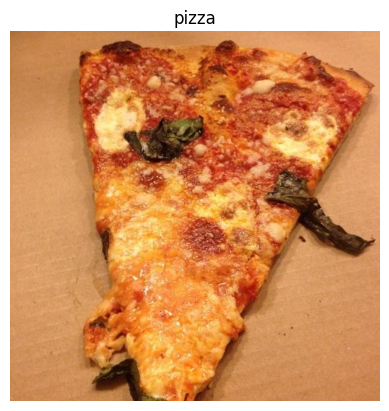

In [12]:
#view a random image from the training dataset
img = view_random_image(target_dir ='pizza_steak/train/',
                        target_class ='pizza')

In [13]:
# view the image shape
img.shape

(512, 512, 3)

In [14]:
#get all the pixel values between 0 and 1
img/225.

array([[[0.77333333, 0.50222222, 0.25777778],
        [0.76444444, 0.49333333, 0.24888889],
        [0.75111111, 0.48      , 0.23555556],
        ...,
        [1.01333333, 0.71555556, 0.47111111],
        [1.00444444, 0.70666667, 0.46222222],
        [1.        , 0.70222222, 0.45777778]],

       [[0.76888889, 0.49777778, 0.25333333],
        [0.76      , 0.48888889, 0.24444444],
        [0.75555556, 0.48444444, 0.24      ],
        ...,
        [1.00888889, 0.71111111, 0.46666667],
        [1.00444444, 0.70666667, 0.46222222],
        [1.        , 0.70222222, 0.45777778]],

       [[0.76444444, 0.49333333, 0.24888889],
        [0.76      , 0.48888889, 0.24444444],
        [0.75555556, 0.48444444, 0.24      ],
        ...,
        [1.00444444, 0.70666667, 0.46222222],
        [1.        , 0.70222222, 0.45777778],
        [1.        , 0.70222222, 0.45777778]],

       ...,

       [[0.85777778, 0.57777778, 0.35111111],
        [0.87555556, 0.59555556, 0.36888889],
        [0.88888889, 0

Building an end to end convolutional neural network(cnn)

In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#set a random seed
tf.random.set_seed(42)

#preprocess data (get all of the pixel values between 0 and 1, also called scaling/normalisation)
train_datagen = ImageDataGenerator(rescale =1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
#setup path to our data directories

train_dir = '/content/pizza_steak/train'
test_dir = '/content/pizza_steak/test'

#impory data from directories and turn it into batches

train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode = 'binary',
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode ='binary',
                                               seed=42)


#Build a CNN model (same as the tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation='relu',
                           input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10,3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding='valid'),
    tf.keras.layers.Conv2D(10,3, activation='relu'),
    tf.keras.layers.Conv2D(10,3, activation= 'relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

#compile the model

model_1.compile(loss= 'binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])
#fit the model

history_1 = model_1.fit(train_data,
                      epochs=5,
                      steps_per_epoch=len(train_data),
                      validation_data=valid_data,
                      validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 223ms/step - accuracy: 0.5476 - loss: 0.6850 - val_accuracy: 0.7340 - val_loss: 0.5077
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.7754 - loss: 0.4792 - val_accuracy: 0.8180 - val_loss: 0.4515
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.7839 - loss: 0.4682 - val_accuracy: 0.8440 - val_loss: 0.3778
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8156 - loss: 0.4009 - val_accuracy: 0.8620 - val_loss: 0.3371
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.8629 - loss: 0.3385 - val_accuracy: 0.8680 - val_loss: 0.3088


note if the above cell is taking longer than -10 second make sure you change the runtime

In [16]:
#get a model summary

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

In [18]:
#Using the same model as before
# set random seed

tf.random.set_seed(42)

#create a model to replicate the tensorflow playground
model_2 =tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation= 'relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

#compile the model
model_2.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

#Fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data= valid_data,
                        validation_steps = len(valid_data))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - accuracy: 0.4882 - loss: 0.7089 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.4625 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.5047 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.4931 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.5205 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932


In [20]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │       602,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,806,425 (6.89 MB)

 Trainable params: 602,141 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,204,284 (4.59 MB)

In [22]:
#lets improve our cnn
tf.random.set_seed(42)

#create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')

])

#compile the model

model_3.compile(loss = 'binary_crossentropy',
                optimizer =tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

#fit the model
model_3.fit(train_data,
            epochs=5,
            steps_per_epoch= len(train_data),
            validation_data= valid_data,
            validation_steps=len(valid_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.6005 - loss: 3.4993 - val_accuracy: 0.6860 - val_loss: 1.3948
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.6606 - loss: 1.5681 - val_accuracy: 0.7900 - val_loss: 0.4642
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7820 - loss: 0.5153 - val_accuracy: 0.7720 - val_loss: 0.4611
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.7866 - loss: 0.4697 - val_accuracy: 0.7380 - val_loss: 0.5331
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.7093 - loss: 0.5823 - val_accuracy: 0.7000 - val_loss: 0.6205
